# Part 1: Exploratory Data Analysis (EDA) in Jupyter Notebook

## Set up

In [5]:
!pip install seaborn
!pip install numpy


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('movies.csv')

In [10]:
df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [12]:
df.shape

(9742, 3)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [25]:
df.describe()

,movieId,Year
count,9742.000000,9729.000000
mean,42200.353623,1994.613629
std,52160.494854,18.535219
min,1.000000,1902.000000
25%,3248.250000,1988.000000
50%,7300.000000,1999.000000
75%,76232.000000,2008.000000
max,193609.000000,2018.000000


In [26]:
df.isnull().sum() 

movieId     0
title       0
genres      0
Year       13
Title       0
dtype: int64

## Splitting Title and Year

In [34]:
# Extracting year from title (looking for (YYYY) pattern)
df['Year'] = df['title'].str.extract(r'\((\d{4})\)') 

In [35]:
# Remove the year from the title
df['Title'] = df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

In [36]:
# Converting year from text to numbers
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [37]:
# Verifying 
df[['title', 'Title', 'Year']].head()

,title,Title,Year
0,Toy Story (1995),Toy Story,1995.0
1,Jumanji (1995),Jumanji,1995.0
2,Grumpier Old Men (1995),Grumpier Old Men,1995.0
3,Waiting to Exhale (1995),Waiting to Exhale,1995.0
4,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0


## Organizing/Cleaning Genres

In [38]:
df['genres'].head()

0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: str

In [39]:
all_genres = df['genres'].str.split('|').explode().unique()
print("Unique genres:", all_genres)
print("Number of unique genres:", len(all_genres))

Unique genres: <StringArray>
[         'Adventure',          'Animation',           'Children',
             'Comedy',            'Fantasy',            'Romance',
              'Drama',             'Action',              'Crime',
           'Thriller',             'Horror',            'Mystery',
             'Sci-Fi',                'War',            'Musical',
        'Documentary',               'IMAX',            'Western',
          'Film-Noir', '(no genres listed)']
Length: 20, dtype: str
Number of unique genres: 20


In [40]:
genre_counts = df['genres'].str.split('|').explode().value_counts()
print(genre_counts)

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64


## Creating Visualizations

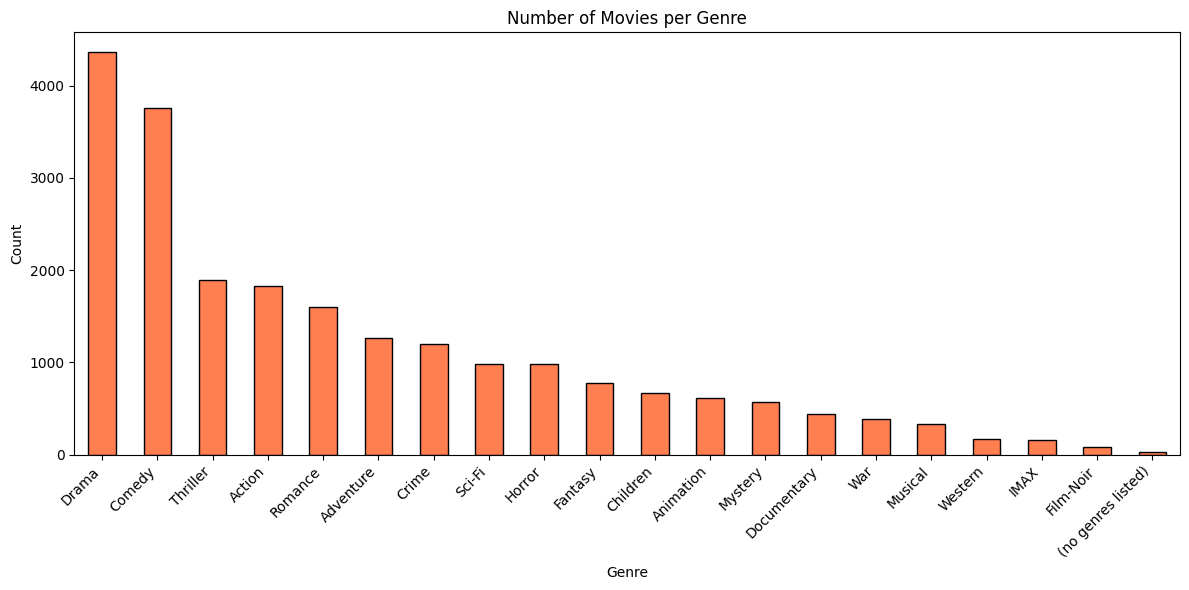

In [41]:
# Bar chart: How many movies are in each genre
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

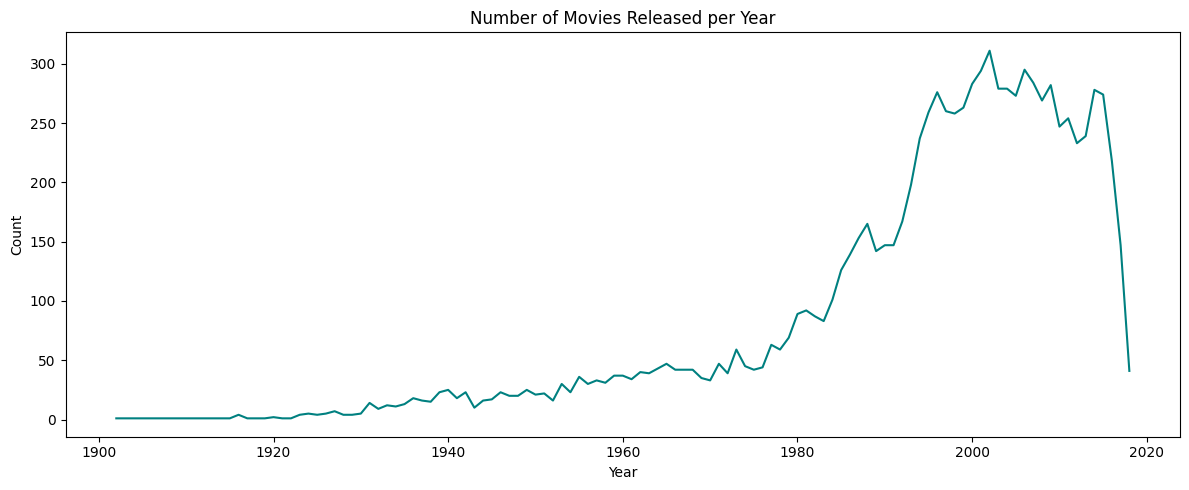

In [42]:
# Line chart: How many movies were released each year
movies_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
movies_per_year.plot(kind='line', color='teal')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

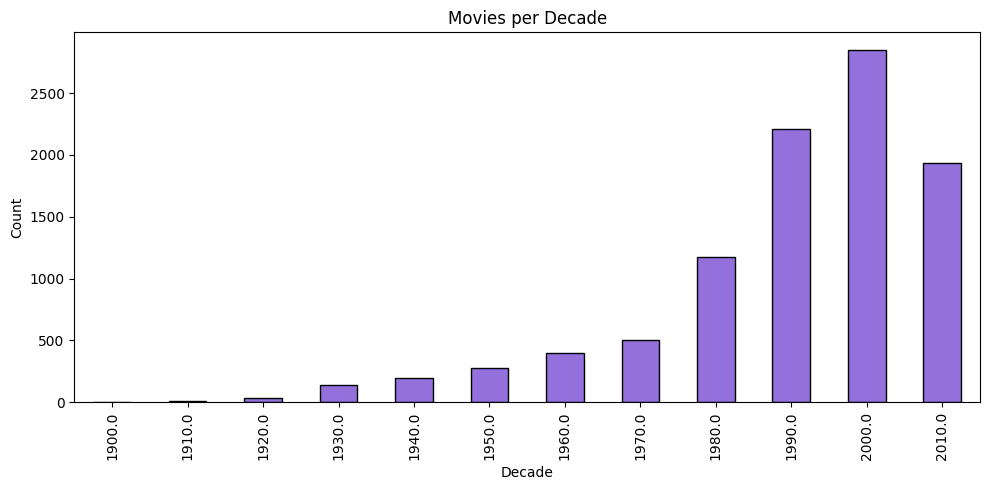

In [44]:
# Movies per Decade
df['Decade'] = (df['Year'] // 10) * 10
decade_counts = df['Decade'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
decade_counts.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

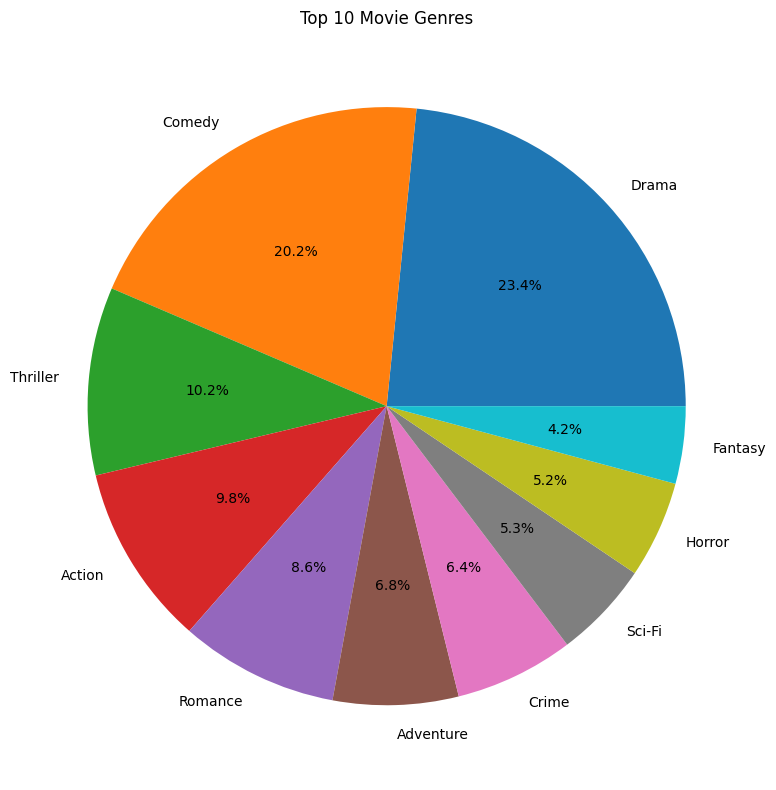

In [45]:
# Pie Chart: Top 10 most common genres
plt.figure(figsize=(8, 8))
genre_counts.head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Movie Genres')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Generating Clean Dataset

In [47]:
df_clean = df[['Title', 'Year', 'Genre(s)']]

In [48]:
df_clean.to_csv('movies_clean.csv', index=False)

print("Saved movies_clean.csv")
df_clean.head() 

Saved movies_clean.csv


,Title,Year,genres
0,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji,1995.0,Adventure|Children|Fantasy
2,Grumpier Old Men,1995.0,Comedy|Romance
3,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,Father of the Bride Part II,1995.0,Comedy


In [ ]:
# PART 2: Streamlit APP